# Notebook 04 — PCA, News Shock Features & Final Feature Matrix

**Goal:** Merge the technical indicator matrix (from Day 2) with the daily news embeddings
(from Day 3), reduce the 384-dimensional embedding space via PCA, add news shock features,
and produce the single `final_features.csv` that all modelling notebooks will use.

**Key leakage-prevention rules:**
- PCA is **fit on training data only** (`index < TRAIN_END`) and then applied to val/test.
- News shock z-scores use rolling windows — no future data leaks in by construction.
- Zero-vector imputation for days with no headlines is applied *before* PCA so that the
  PCA basis is learned only from real embeddings.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils import (
    DATA_PROCESSED, TRAIN_END, VAL_END,
    PCA_VARIANCE_THRESHOLD, EMBEDDING_DIM,
    get_temporal_split,
)
from src.embeddings import fit_pca_on_train
from src.features import compute_news_shock_features

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print(f'TRAIN_END={TRAIN_END}  VAL_END={VAL_END}  PCA_VARIANCE_THRESHOLD={PCA_VARIANCE_THRESHOLD}')

TRAIN_END=2021-01-01  VAL_END=2022-07-01  PCA_VARIANCE_THRESHOLD=0.7


---
## 1. Load & Merge

We do a **left join** on the technical feature matrix so that every trading day is preserved.
Days that had no headlines will have `NaN` in all embedding columns after the merge — we
handle those in the next section.

In [2]:
# --- technical features (DatetimeIndex) ---
tech = pd.read_csv(DATA_PROCESSED / 'technical_features.csv', index_col=0, parse_dates=True)
tech.index.name = 'Date'
print(f'Technical features: {tech.shape}  {tech.index[0].date()} → {tech.index[-1].date()}')

# --- daily news embeddings (date column) ---
news = pd.read_csv(DATA_PROCESSED / 'daily_news_embeddings.csv', parse_dates=['date'])
news = news.set_index('date')
news.index.name = 'Date'
print(f'News embeddings:    {news.shape}  {news.index[0].date()} → {news.index[-1].date()}')

Technical features: (3828, 18)  2008-10-15 → 2023-12-29
News embeddings:    (3464, 386)  2008-01-02 → 2023-12-29


In [3]:
# Left join: keep every trading day from technical features
merged = tech.join(news, how='left')
print(f'Merged shape: {merged.shape}')
print(f'Rows with any NaN (pre-imputation): {merged.isna().any(axis=1).sum()}')

Merged shape: (3828, 404)
Rows with any NaN (pre-imputation): 441


---
## 2. Impute Missing News Days

For trading days with no headlines we:
- Set `has_news = 0` (binary flag the model can use as a feature)
- Fill `headline_count` and `embedding_magnitude` with `0`
- Fill all `emb_0…emb_383` columns with `0` (zero-vector — neutral in embedding space)

This approach is preferable to dropping rows (we'd lose years of price history) and to mean
imputation (which would inject spurious "average sentiment" signal).

In [4]:
emb_cols = [f'emb_{i}' for i in range(EMBEDDING_DIM)]
meta_cols = ['headline_count', 'embedding_magnitude']

# Binary coverage flag (before filling NaNs)
merged['has_news'] = merged['headline_count'].notna().astype(int)

no_news_days = (merged['has_news'] == 0).sum()
print(f'Trading days with no news coverage: {no_news_days} '
      f'({100 * no_news_days / len(merged):.1f}% of all trading days)')

# Zero-fill missing embedding + metadata columns
fill_cols = emb_cols + meta_cols
merged[fill_cols] = merged[fill_cols].fillna(0)

print(f'Remaining NaNs after imputation: {merged[fill_cols].isna().sum().sum()}')

Trading days with no news coverage: 441 (11.5% of all trading days)
Remaining NaNs after imputation: 0


---
## 3. PCA on Embedding Columns

384 embedding dimensions would dominate the feature matrix and cause overfitting.
We reduce them to however many principal components are needed to explain
`PCA_VARIANCE_THRESHOLD` (50%) of training-set embedding variance.

**Leakage guard:** `fit_pca_on_train` fits *only on training rows* (`index < TRAIN_END`),
then applies the same projection to val and test.

Training rows used to fit PCA: 3075
PCA: 79 components retain 0.701 variance
PCA output columns: 79


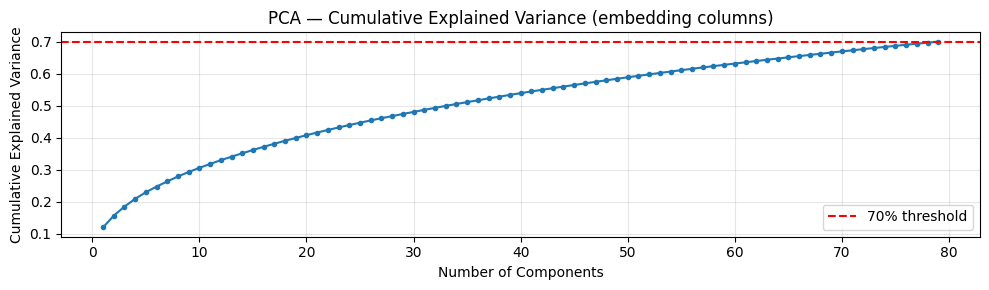

In [5]:
train_mask = merged.index < TRAIN_END
print(f'Training rows used to fit PCA: {train_mask.sum()}')

pca_model, merged = fit_pca_on_train(merged, train_mask, variance_threshold=PCA_VARIANCE_THRESHOLD)

pca_cols = [c for c in merged.columns if c.startswith('news_pca_')]
print(f'PCA output columns: {len(pca_cols)}')

# Scree-style cumulative variance plot
cumvar = np.cumsum(pca_model.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=3)
ax.axhline(PCA_VARIANCE_THRESHOLD, color='red', linestyle='--',
           label=f'{PCA_VARIANCE_THRESHOLD:.0%} threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance (embedding columns)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. News Shock Features

Beyond the compressed embeddings we add two interpretable news-shock signals:
- **`news_volume_zscore`** — rolling 20-day z-score of `headline_count`: are there unusually
  many headlines today?
- **`news_magnitude_zscore`** — rolling 20-day z-score of `embedding_magnitude`: is today's
  aggregate embedding unusually strong (high-conviction news)?
- Binary `_shock` flags at |z| > 2.

These are computed on the *imputed* (zero-filled) series, so zero-news days pull the mean
down and make real-news days stand out more — which is the intended behaviour.

In [6]:
shock_input = merged[meta_cols].copy()  # headline_count, embedding_magnitude (already 0-filled)
shock_features = compute_news_shock_features(shock_input)

merged = merged.join(shock_features)
shock_cols = shock_features.columns.tolist()
print(f'News shock columns added: {shock_cols}')
print(merged[shock_cols].describe().round(3))

News shock columns added: ['news_volume_zscore', 'news_volume_shock', 'news_magnitude_zscore', 'news_magnitude_shock']
       news_volume_zscore  news_volume_shock  news_magnitude_zscore  \
count            3824.000           3828.000               3824.000   
mean                0.015              0.044                  0.001   
std                 0.982              0.205                  0.977   
min                -2.573              0.000                 -4.194   
25%                -0.715              0.000                 -0.612   
50%                -0.100              0.000                 -0.072   
75%                 0.669              0.000                  0.589   
max                 4.135              1.000                  3.461   

       news_magnitude_shock  
count              3828.000  
mean                  0.047  
std                   0.212  
min                   0.000  
25%                   0.000  
50%                   0.000  
75%                   0.000  
m

---
## 5. Drop Raw Embedding & Metadata Columns

We no longer need the 384 raw `emb_*` columns (replaced by PCA components) or the raw
`headline_count` / `embedding_magnitude` columns (summarised by shock features).
Keeping them would leak the raw inputs and bloat the feature matrix.

In [7]:
# emb_cols were already dropped inside fit_pca_on_train; only meta_cols remain to drop
cols_to_drop = [c for c in meta_cols if c in merged.columns]
merged = merged.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} raw columns: {cols_to_drop}')
print(f'Final matrix shape: {merged.shape}')

Dropped 2 raw columns: ['headline_count', 'embedding_magnitude']
Final matrix shape: (3828, 102)


---
## 6. Final Feature Matrix Inspection

Verify shape, column names grouped by type, and absence of NaN values.

In [8]:
all_cols = merged.columns.tolist()

tech_cols  = [c for c in all_cols if c not in pca_cols + shock_cols + ['has_news', 'target']]
news_cols  = pca_cols + shock_cols + ['has_news']

print(f'=== Final feature matrix: {merged.shape[0]} rows × {merged.shape[1]} cols ===')
print(f'  Date range : {merged.index[0].date()} → {merged.index[-1].date()}')
print()
print(f'Technical features ({len(tech_cols)}):')
for c in tech_cols:
    print(f'  {c}')
print()
print(f'News features ({len(news_cols)}):')
for c in news_cols:
    print(f'  {c}')
print()
print('Target: target')
print()

nan_counts = merged.isna().sum()
has_nans = nan_counts[nan_counts > 0]
if len(has_nans):
    print('Columns with NaN:')
    print(has_nans)
else:
    print('NaN check: clean — no NaN values in final matrix.')

=== Final feature matrix: 3828 rows × 102 cols ===
  Date range : 2008-10-15 → 2023-12-29

Technical features (17):
  return_1d
  return_5d
  return_10d
  price_to_ma10
  price_to_ma20
  price_to_ma50
  price_to_ma100
  price_to_ma200
  volatility_5d
  volatility_10d
  volatility_20d
  volume_change
  volume_to_avg20
  vix_level
  vix_change_1d
  vix_change_5d
  vix_to_ma20

News features (84):
  news_pca_0
  news_pca_1
  news_pca_2
  news_pca_3
  news_pca_4
  news_pca_5
  news_pca_6
  news_pca_7
  news_pca_8
  news_pca_9
  news_pca_10
  news_pca_11
  news_pca_12
  news_pca_13
  news_pca_14
  news_pca_15
  news_pca_16
  news_pca_17
  news_pca_18
  news_pca_19
  news_pca_20
  news_pca_21
  news_pca_22
  news_pca_23
  news_pca_24
  news_pca_25
  news_pca_26
  news_pca_27
  news_pca_28
  news_pca_29
  news_pca_30
  news_pca_31
  news_pca_32
  news_pca_33
  news_pca_34
  news_pca_35
  news_pca_36
  news_pca_37
  news_pca_38
  news_pca_39
  news_pca_40
  news_pca_41
  news_pca_42
  news_pca

---
## 7. Train / Val / Test Split Sizes

In [9]:
train, val, test = get_temporal_split(merged)

for name, split in [('Train', train), ('Val', val), ('Test', test)]:
    start    = split.index[0].date()
    end      = split.index[-1].date()
    pct      = 100 * len(split) / len(merged)
    up_rate  = split['target'].mean()
    news_pct = 100 * split['has_news'].mean()
    print(
        f'{name:5s}: {len(split):4d} rows  ({start} → {end})  '
        f'{pct:.1f}%  |  up_rate={up_rate:.3f}  news_coverage={news_pct:.1f}%'
    )

Train: 3075 rows  (2008-10-15 → 2020-12-31)  80.3%  |  up_rate=0.557  news_coverage=85.9%
Val  :  376 rows  (2021-01-04 → 2022-06-30)  9.8%  |  up_rate=0.537  news_coverage=99.5%
Test :  377 rows  (2022-07-01 → 2023-12-29)  9.8%  |  up_rate=0.512  news_coverage=98.4%


---
## 8. Save Final Feature Matrix

In [10]:
out_path = DATA_PROCESSED / 'final_features.csv'
merged.to_csv(out_path)
print(f'Saved {merged.shape[0]} rows × {merged.shape[1]} cols → {out_path}')

Saved 3828 rows × 102 cols → /Users/shirleycheung/Desktop/FSA_AI_capstone_project/notebooks/../data/processed/final_features.csv


---
## 9. Summary

| Output | Value |
|--------|-------|
| **Saved file** | `data/processed/final_features.csv` |
| **Matrix shape** | 3,828 rows × 102 cols |
| **Date range** | 2008-10-15 → 2023-12-29 |
| **Technical features** | 17 (returns, MA ratios, volatility, volume, VIX) |
| **PCA news components** | 79 (`news_pca_0` … `news_pca_78`) — 70% of embedding variance |
| **Shock features** | 4 (`news_volume_zscore`, `news_volume_shock`, `news_magnitude_zscore`, `news_magnitude_shock`) |
| **Coverage flag** | 1 (`has_news`) |
| **Total features** | 101 (+ 1 target column) |
| **No-news days imputed** | 441 (11.5%) — zero-vector fill |
| **Residual NaNs** | 4 rows in shock z-scores (first 20-day rolling window) |

**Key leakage-prevention steps:**
- PCA fit on training rows only (`index < 2021-01-01`), then applied to val/test.
- Zero-imputation for missing news days before PCA — no future sentiment leaks in.
- Shock z-scores computed with rolling windows — no look-ahead by construction.

This file is the single input to all modelling notebooks (05, 06) and the Streamlit dashboard.